# Preliminary 2d CNN

In [1]:
import numpy as np
from numpy.typing import NDArray
import awkward as ak
import pandas as pd
import numpy as np
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import ROOT

2026-04-10 12:36:54.407064: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 12:36:54.407305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 12:36:54.446223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-10 12:36:55.586123: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Read labels

From manual (visual) inspection

In [2]:
# Read labels
dflabel = pd.read_csv("./events_f0.csv")
last_valid = dflabel["type"].last_valid_index()

# Encode labels
le = LabelEncoder()
y = le.fit_transform(dflabel.iloc[:last_valid]["type"])


## Read TPC data

And project onto 2D.

In [4]:
ROOT.EnableImplicitMT()  # type: ignore

rdf = ROOT.RDataFrame("SimpleTree", ["./Outputs/simple_tree.root"])  # type: ignore

arr = ak.from_rdataframe(rdf, columns=("X", "Y", "Z", "Ef0", "fRun", "fEntry"))


def prepare_spatial(events: ak.Array, rebin_factor=2, max_coord=128):
    """
    Project 3D hits to XY plane and rebin into binary occupancy grid.
    Drops Z, deduplicates (X,Y) pairs, rebins, returns (N_events, grid_size, grid_size, 1).

    Args:
        events: awkward array (N_events, variable_hits, 3)
        rebin_factor: bin aggregation factor
        max_coord: maximum coordinate value in input (e.g., 128 for [0, 127])
    """
    grid_size = max_coord // rebin_factor
    grids = np.zeros((len(events), grid_size, grid_size, 1), dtype=np.float32)

    for i, event in enumerate(events):
        # X
        x = ak.to_numpy(event["X"]).astype(int)
        # Y
        y = ak.to_numpy(event["Y"]).astype(int)
        xy = np.column_stack([x, y])
        # Rebin
        xy_rebinned = (xy // rebin_factor).astype(int)
        # Find unique
        unique_xy = np.unique(xy_rebinned, axis=0)
        unique_xy = unique_xy[
            (unique_xy >= 0).all(axis=1) & (unique_xy < grid_size).all(axis=1)
        ]
        grids[i, unique_xy[:, 0], unique_xy[:, 1], 0] = 1

    return grids


max_coord = 128
rebin_factor = 2

X_space = prepare_spatial(arr, rebin_factor=rebin_factor, max_coord=max_coord)[
    :last_valid
]
X_scalar_nonorm = ak.to_numpy(arr["Ef0"])[:last_valid].reshape(-1, 1)
std_scaler = StandardScaler()
X_scalar = std_scaler.fit_transform(X_scalar_nonorm)

# Declare model to train

A 2d CNN to lear spatial features and a dense one to use the f0 Si data.

In [5]:
def build_fused_model(input_shape=(64, 64, 1), num_classes=3):
    """
    Fused architecture: 2D CNN for spatial features + dense net for final classification.
    
    Args:
        input_shape: grid dimensions (H, W, C)
        num_classes: number of classification categories
    
    Returns:
        keras Model with 2 inputs (image, scalar), 1 output (class)
    """
    # Input 1: 2D spatial data
    img_input = keras.Input(shape=input_shape, name='spatial')
    
    # CNN backbone: learn spatial features
    x = keras.layers.Conv2D(16, 3, padding='same', activation='relu')(img_input)
    x = keras.layers.MaxPooling2D(2)(x)
    x = keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D(2)(x)
    x = keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    spatial_features = keras.layers.GlobalAveragePooling2D()(x)
    
    # Input 2: scalar feature
    scalar_input = keras.Input(shape=(1,), name='scalar')
    
    # Merge spatial + scalar
    merged = keras.layers.Concatenate()([spatial_features, scalar_input])
    
    # Dense classification head
    x = keras.layers.Dense(128, activation='relu')(merged)
    x = keras.layers.Dropout(0.3)(x)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs=[img_input, scalar_input], outputs=outputs)
    return model

And now train! Of course we have a very small dataset...

In [6]:
X_space_train, X_space_test, X_scalar_train, X_scalar_test, y_train, y_test = (
    train_test_split(X_space, X_scalar, y, test_size=0.1, random_state=42)
)

model = build_fused_model(
    input_shape=(max_coord // rebin_factor, max_coord // rebin_factor, 1),
    num_classes=len(le.classes_),
)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spatial             │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        160 │ spatial[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ conv2d_2[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scalar (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ scalar[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,195 (157.01 KB)

 Trainable params: 40,195 (157.01 KB)

 Non-trainable params: 0 (0.00 B)

2026-04-10 12:38:57.636453: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
history = model.fit(
    [X_space_train, X_scalar_train], y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5446 - loss: 1.0233 - val_accuracy: 0.5111 - val_loss: 0.9692
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6064 - loss: 0.8700 - val_accuracy: 0.5111 - val_loss: 0.9177
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6114 - loss: 0.8244 - val_accuracy: 0.5333 - val_loss: 0.9187
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5891 - loss: 0.8021 - val_accuracy: 0.5333 - val_loss: 0.9106
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6188 - loss: 0.8094 - val_accuracy: 0.5333 - val_loss: 0.9030
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6040 - loss: 0.7660 - val_accuracy: 0.5333 - val_loss: 0.9392
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5817 - loss: 0.7923 - val_accuracy: 0.5556 - val_loss: 0.9045
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6436 - loss: 0.7631 - val_accuracy: 0.5333 - v

And now inspect the output

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
              precision    recall  f1-score   support

      Binary       0.93      0.93      0.93        30
       Multi       0.00      0.00      0.00         0
       Other       0.90      0.90      0.90        20

    accuracy                           0.92        50
   macro avg       0.61      0.61      0.61        50
weighted avg       0.92      0.92      0.92        50



/home/miguel/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/miguel/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/miguel/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/miguel/venv

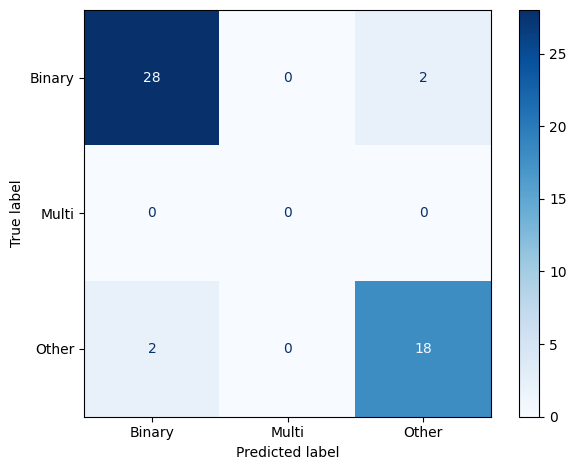

In [8]:
y_pred = np.argmax(model.predict([X_space_test, X_scalar_test]), axis=1)
y_true = y_test

print(classification_report(y_true, y_pred, labels=[0, 1, 2], target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")
plt.tight_layout()
